# Anytime LaCAM versus MAPF-LNS

Load and analyse an S2 result file. Benchmark generation is handled separately by `scripts/benchmark_s2.py`; this notebook never runs solvers or modifies benchmark results.

In [45]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent


## Inputs

In [ ]:
RESULTS_FILE = ROOT / "notebooks/benchmarks/s2_results.jsonl"
NEIGHBORHOOD_SIZES = (4, 8, 16, 32)

## Load results and identify failures

In [47]:
def read_jsonl(path):
    with Path(path).open(encoding="utf-8") as lines:
        records = []
        for line in lines:
            if not line.strip():
                continue
            record = json.loads(line)
            record.pop("anytime_trace", None)
            record.pop("lns_trace", None)
            records.append(record)
        return records


source_records = read_jsonl(RESULTS_FILE)
if not source_records or any(record.get("task") is None for record in source_records):
    raise ValueError("Results must contain task indices")

task_count = max(int(record["task"]) for record in source_records) + 1
records_by_key = {
    (int(record["task"]), int(record.get("lns_neighborhood_size", 4))): record
    for record in source_records
}
records = list(records_by_key.values())

successful_sizes = {task: set() for task in range(task_count)}
for record in records:
    if record.get("status") == "success":
        successful_sizes[int(record["task"])].add(
            int(record.get("lns_neighborhood_size", 4))
        )
required_sizes = set(NEIGHBORHOOD_SIZES)
incomplete_tasks = [
    task for task, sizes in successful_sizes.items() if not required_sizes <= sizes
]
errors = {}
for record in source_records:
    if record.get("status") != "success":
        errors.setdefault(int(record["task"]), record.get("error", "error"))
failure_summary = pd.Series(
    [errors.get(task, "missing result") for task in incomplete_tasks],
    name="reason",
).value_counts().rename_axis("reason").to_frame("instances")
print(f"{task_count - len(incomplete_tasks)}/{task_count} instances complete")
display(failure_summary)

500/500 instances complete


,instances
reason,


## Results

,instances,mean,median,best fraction
Anytime LaCAM,500,0.097778,0.047253,0.254
LaCAM + LNS n4,500,0.157519,0.072668,0.206
LaCAM + LNS n8,500,0.146334,0.066347,0.260
LaCAM + LNS n16,500,0.112752,0.044493,0.264
LaCAM + LNS n32,500,0.068227,0.028004,0.076


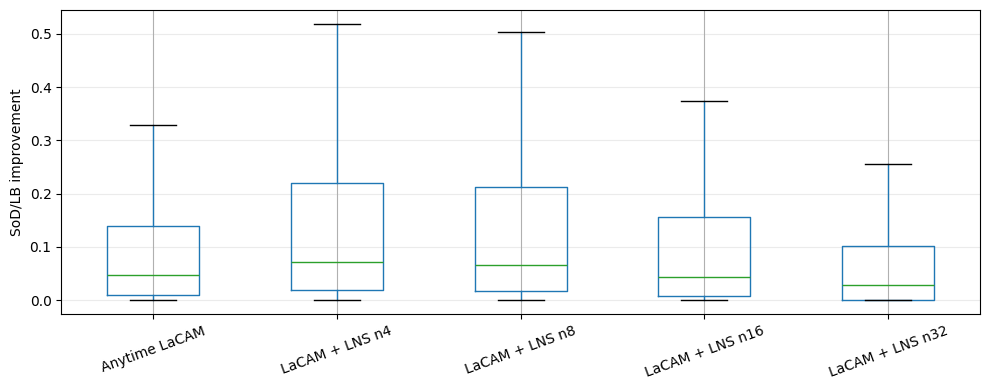

In [48]:
rows = []
for record in records:
    if record.get("status") != "success":
        continue
    rows.append({
        "instance": record["instance"],
        "neighborhood": int(record.get("lns_neighborhood_size", 4)),
        "Anytime LaCAM": (record["initial_soc"] - record["anytime_best_soc"]) / record["lower_bound_soc"],
        "LNS": (record["initial_soc"] - record["lns_final_soc"]) / record["lower_bound_soc"],
    })
quality = pd.DataFrame(rows)
improvements = quality.pivot(index="instance", columns="neighborhood", values="LNS")
improvements.columns = [f"LaCAM + LNS n{size}" for size in improvements.columns]
improvements.insert(0, "Anytime LaCAM", quality.groupby("instance")["Anytime LaCAM"].first())
improvements = improvements.dropna()
summary = improvements.agg(["mean", "median"]).T
summary.insert(0, "instances", len(improvements))
best = improvements.max(axis=1)
summary["best fraction"] = [np.isclose(improvements[column], best).mean() for column in improvements]
display(summary)

ax = improvements.boxplot(figsize=(10, 4), showfliers=False)
ax.set_ylabel("SoD/LB improvement")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Example improvement curves

Show the three instances with the largest anytime-LaCAM advantage, the three with the largest LaCAM + LNS advantage, and three additional instances whose initial solutions were found latest. Every instance is displayed in a separate figure. Traces are reread only for these examples rather than retained for every result. Each LNS curve is shifted by the initial LaCAM solution time, matching the shared 100-second benchmark horizon.

S2 does not perform repetitions: every sampled instance uses one LaCAM run (seed 0), whose initial solution is passed to one LNS run per neighbourhood size (seed 1).

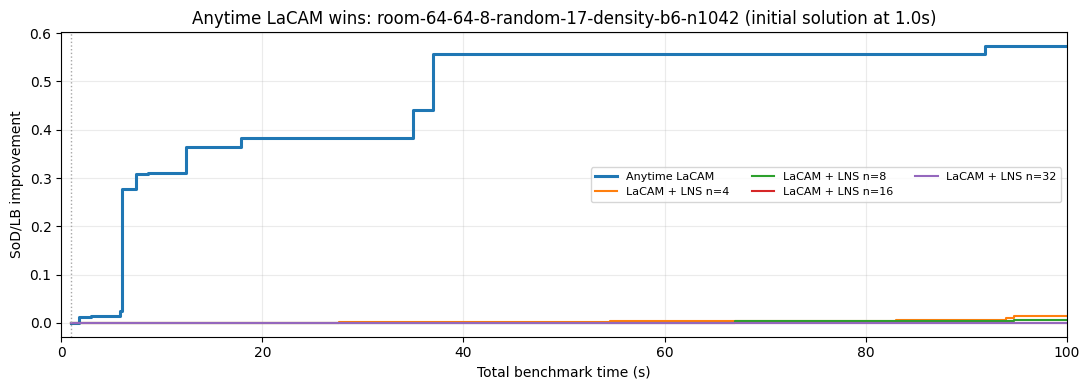

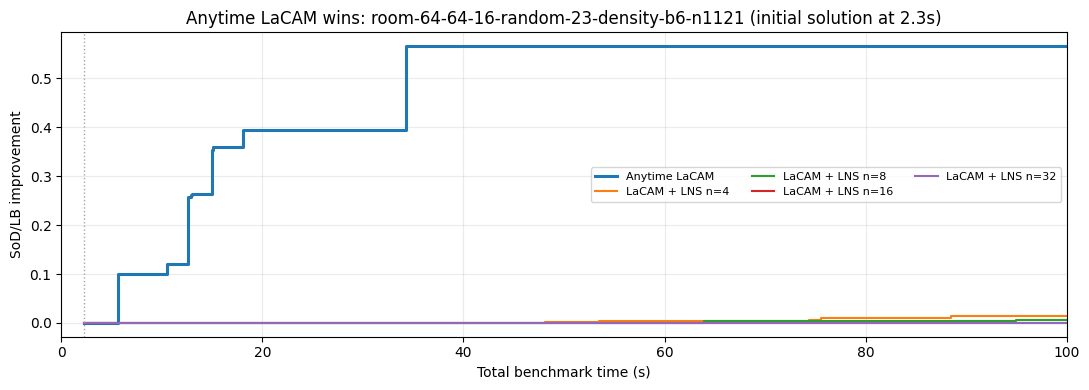

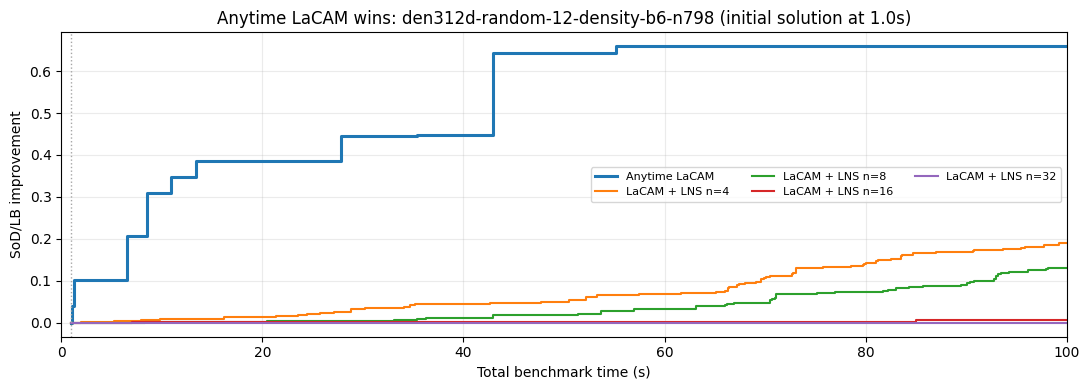

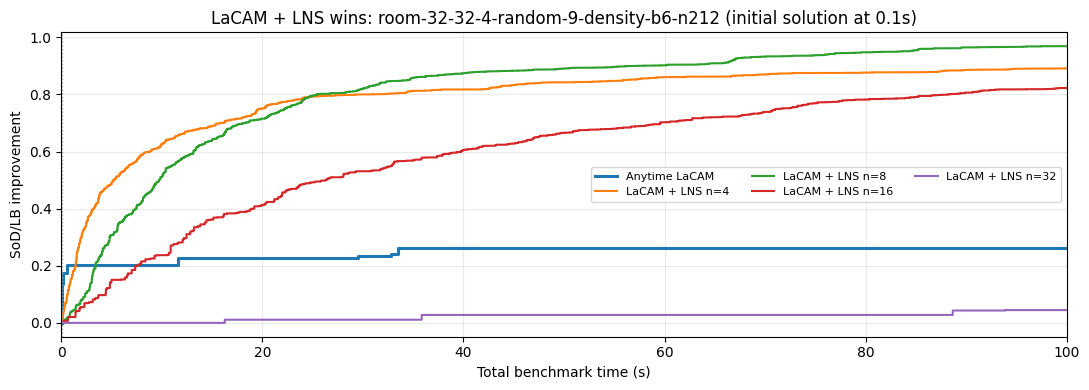

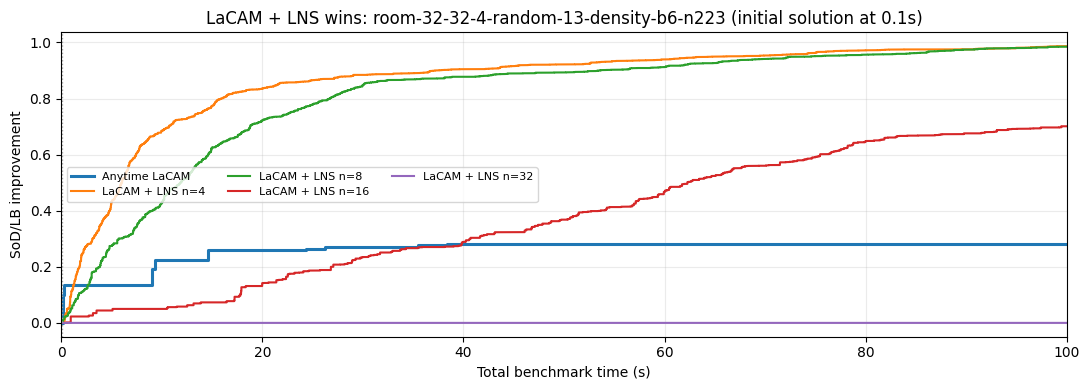

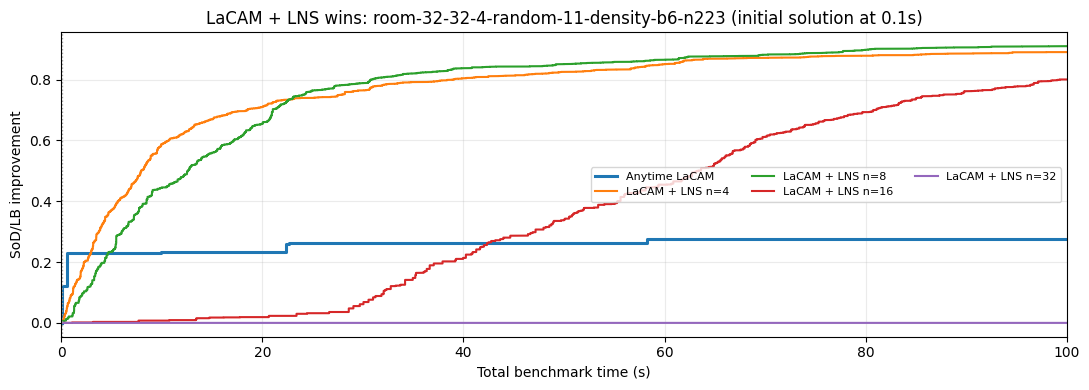

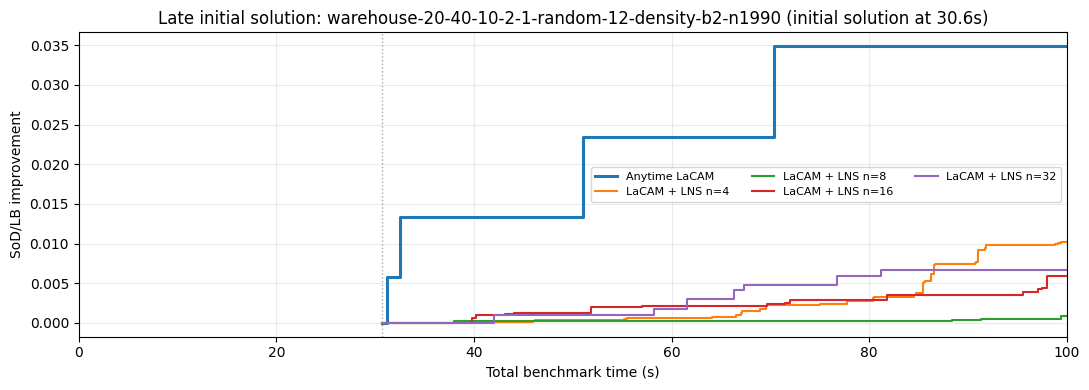

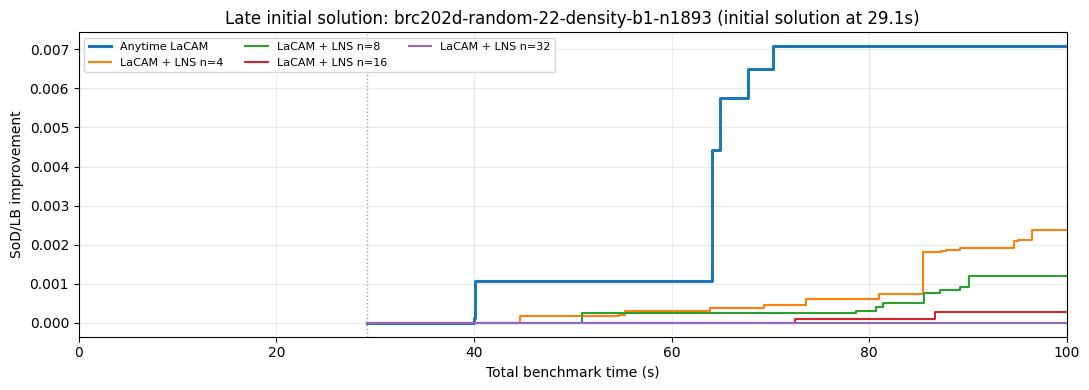

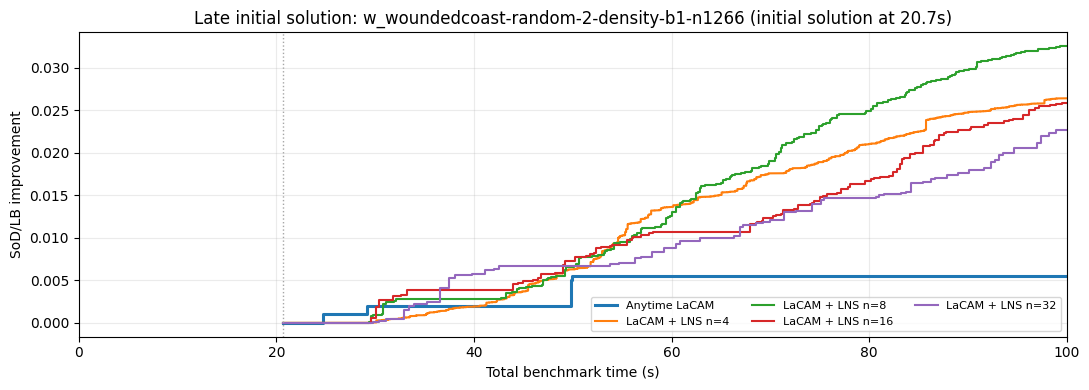

In [49]:
lns_columns = [column for column in improvements if column.startswith("LaCAM + LNS")]
advantage = improvements["Anytime LaCAM"] - improvements[lns_columns].max(axis=1)
example_groups = {
    "Anytime LaCAM wins": advantage[advantage > 0].nlargest(3).index.tolist(),
    "LaCAM + LNS wins": advantage[advantage < 0].nsmallest(3).index.tolist(),
}
already_selected = {
    instance for instances in example_groups.values() for instance in instances
}
initial_times = pd.Series({
    record["instance"]: float(record["initial_seconds"])
    for record in records
    if record.get("status") == "success" and record["instance"] in improvements.index
})
example_groups["Late initial solution"] = (
    initial_times.drop(index=list(already_selected), errors="ignore")
    .nlargest(3).index.tolist()
)
example_instances = [
    instance for instances in example_groups.values() for instance in instances
]

def read_traces(path, instances):
    selected = {instance: {} for instance in instances}
    with Path(path).open(encoding="utf-8") as lines:
        for line in lines:
            if not line.strip():
                continue
            record = json.loads(line)
            instance = record.get("instance")
            if instance in selected and record.get("status") == "success":
                selected[instance][int(record["lns_neighborhood_size"])] = record
    return selected

example_records = read_traces(RESULTS_FILE, example_instances)
for category, instances in example_groups.items():
    for rank, instance in enumerate(instances, start=1):
        fig, axis = plt.subplots(figsize=(11, 4))
        by_size = example_records[instance]
        first = by_size[min(by_size)]
        initial_seconds = float(first["initial_seconds"])
        initial_soc = float(first["initial_soc"])
        lower_bound = float(first["lower_bound_soc"])
        horizon = initial_seconds + float(first["lns_requested_seconds"])

        anytime = np.asarray(first["anytime_trace"], dtype=float)
        anytime = anytime[anytime[:, 0] <= horizon]
        anytime_seconds = np.r_[anytime[:, 0], horizon]
        anytime_soc = np.r_[anytime[:, 1], anytime[-1, 1]]
        axis.step(
            anytime_seconds, (initial_soc - anytime_soc) / lower_bound,
            where="post", linewidth=2.2, label="Anytime LaCAM",
        )
        for size in sorted(by_size):
            record = by_size[size]
            trace = np.asarray(record.get("lns_trace", []), dtype=float).reshape(-1, 2)
            trace = trace[initial_seconds + trace[:, 0] <= horizon]
            seconds = np.r_[initial_seconds, initial_seconds + trace[:, 0], horizon]
            soc = np.r_[initial_soc, trace[:, 1], trace[-1, 1] if len(trace) else initial_soc]
            axis.step(
                seconds, (initial_soc - soc) / lower_bound, where="post",
                label=f"LaCAM + LNS n={size}",
            )
        axis.axvline(initial_seconds, color="0.65", linestyle=":", linewidth=1)
        axis.set(
            title=(
                f"{category}: {instance} "
                f"(initial solution at {initial_seconds:.1f}s)"
            ),
            xlabel="Total benchmark time (s)",
            ylabel="SoD/LB improvement",
            xlim=(0, horizon),
        )
        axis.grid(alpha=0.25)
        axis.legend(ncol=3, fontsize=8)
        plt.tight_layout()
        plt.show()

## Anytime LaCAM versus virtual-best LaCAM + LNS

,instances,mean,median,wins,ties
Anytime LaCAM,500,0.097778,0.047253,127,0
Virtual-best LaCAM + LNS,500,0.164580,0.082066,373,0


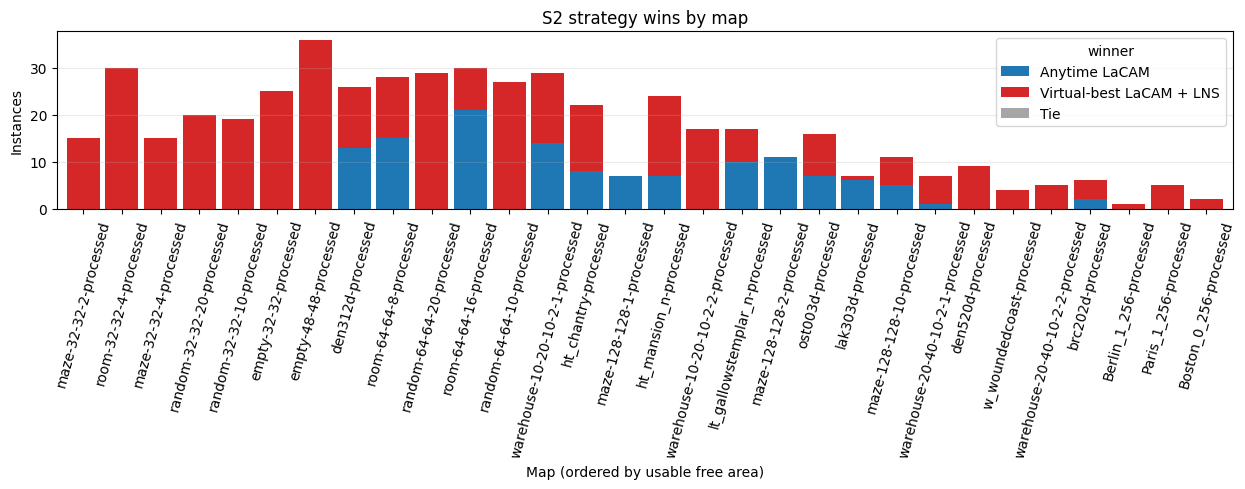

In [50]:
from mapf_anytime.problem import PASSABLE, MapfProblem

lns_columns = [column for column in improvements if column.startswith("LaCAM + LNS")]
comparison = pd.DataFrame({
    "Anytime LaCAM": improvements["Anytime LaCAM"],
    "Virtual-best LaCAM + LNS": improvements[lns_columns].max(axis=1),
})
delta = comparison["Virtual-best LaCAM + LNS"] - comparison["Anytime LaCAM"]
comparison_summary = comparison.agg(["mean", "median"]).T
comparison_summary.insert(0, "instances", len(comparison))
comparison_summary["wins"] = [(delta < 0).sum(), (delta > 0).sum()]
comparison_summary["ties"] = np.isclose(delta, 0).sum()
display(comparison_summary)

manifest_by_instance = {record["instance"]: record["manifest"] for record in records}
map_cache = {}
instance_maps = {}
for instance in comparison.index:
    manifest = Path(manifest_by_instance[instance])
    problem = MapfProblem.from_manifest(manifest if manifest.is_absolute() else ROOT / manifest)
    if problem.map_path not in map_cache:
        data = problem.map()
        map_cache[problem.map_path] = (
            problem.map_path.stem,
            sum(tile in PASSABLE for row in data.grid for tile in row),
        )
    instance_maps[instance] = map_cache[problem.map_path]

outcomes = pd.DataFrame(index=comparison.index)
outcomes[["map", "free_cells"]] = [instance_maps[index] for index in outcomes.index]
outcomes["winner"] = np.where(
    np.isclose(delta, 0), "Tie",
    np.where(delta > 0, "Virtual-best LaCAM + LNS", "Anytime LaCAM"),
)
mapwise = outcomes.groupby(["map", "free_cells", "winner"]).size().unstack(fill_value=0)
mapwise = mapwise.reindex(columns=["Anytime LaCAM", "Virtual-best LaCAM + LNS", "Tie"], fill_value=0)
mapwise = mapwise.reset_index().sort_values(["free_cells", "map"]).set_index("map")

ax = mapwise[["Anytime LaCAM", "Virtual-best LaCAM + LNS", "Tie"]].plot.bar(
    stacked=True, figsize=(max(12, 0.42 * len(mapwise)), 5),
    color=["tab:blue", "tab:red", "0.65"], width=0.85,
)
ax.set_xlabel("Map (ordered by usable free area)")
ax.set_ylabel("Instances")
ax.set_title("S2 strategy wins by map")
ax.tick_params(axis="x", rotation=75)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()